### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

### Load Dataset

In [9]:
df = pd.read_csv("hotel_reviews.csv")

### Dataset Overview

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80122 entries, 0 to 80121
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   offering_id    80122 non-null  int64  
 1   user_id        80122 non-null  str    
 2   overall        80122 non-null  float64
 3   value          72861 non-null  float64
 4   service        72494 non-null  float64
 5   location       64545 non-null  float64
 6   rooms          67724 non-null  float64
 7   cleanliness    72979 non-null  float64
 8   sleep_quality  45586 non-null  float64
 9   review_text    80122 non-null  str    
dtypes: float64(7), int64(1), str(2)
memory usage: 86.6 MB


### Initial Data Inspection

In [14]:
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes)

=== Dataset Shape ===
Rows: 80,122
Columns: 10

=== Column Names ===
['offering_id', 'user_id', 'overall', 'value', 'service', 'location', 'rooms', 'cleanliness', 'sleep_quality', 'review_text']

=== Data Types ===
offering_id        int64
user_id              str
overall          float64
value            float64
service          float64
location         float64
rooms            float64
cleanliness      float64
sleep_quality    float64
review_text          str
dtype: object


NOTES: Since offering_id and user_id do not provide predictive information, they will most not be included in the cleaned dataset. 

###  Data Quality

=== Duplicate Records ===
0

=== Missing Value Summary ===


,Missing Count,Missing Percent
sleep_quality,34536,43.10
location,15577,19.44
rooms,12398,15.47
service,7628,9.52
value,7261,9.06
cleanliness,7143,8.92


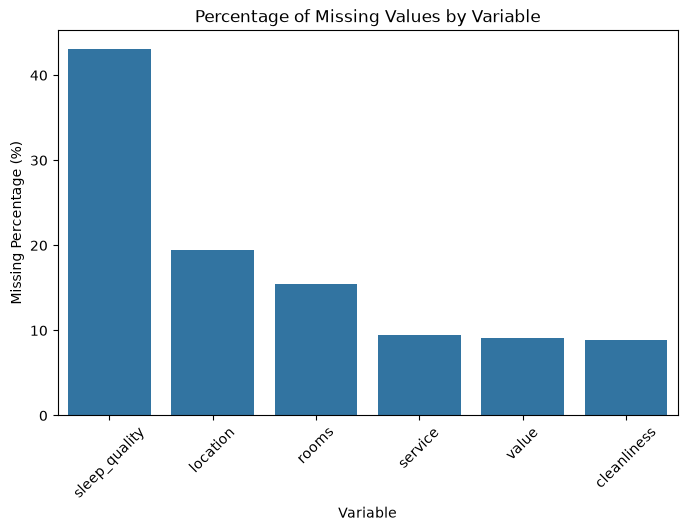

In [19]:
print("=== Duplicate Records ===")
print(df.duplicated().sum())

print("\n=== Missing Value Summary ===")
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent": (df.isnull().mean() * 100).round(2)
})

display(missing_summary[missing_summary["Missing Count"] > 0]

        .sort_values("Missing Count", ascending=False))

missing_pct = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8,5))

sns.barplot(
    x=missing_pct.index,
    y=missing_pct.values
)

plt.title("Percentage of Missing Values by Variable")
plt.xlabel("Variable")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=45)

plt.show()

NOTES: Review_text is not listed amoung the columns with missing values, which is ideal given it will most likely be our target variable. 

=== Overall Rating Distribution ===
overall
1.0     1958
2.0     5124
3.0    15842
4.0    32743
5.0    24455
Name: count, dtype: int64

=== Overall Rating Percentages ===
overall
1.0     2.44
2.0     6.40
3.0    19.77
4.0    40.87
5.0    30.52
Name: proportion, dtype: float64


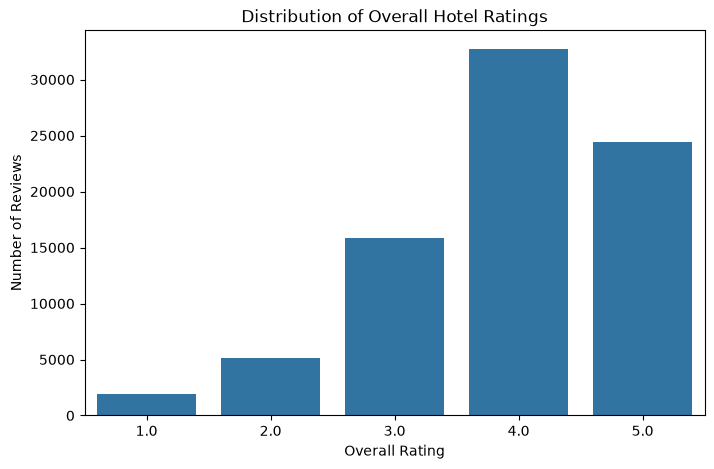

In [ ]:
print("=== Overall Rating Distribution ===")
overall_counts = df["overall"].value_counts().sort_index()
print(overall_counts)
print("\n=== Overall Rating Percentages ===")

overall_pct = (
    df["overall"]
      .value_counts(normalize=True)
      .sort_index() * 100
)

print(overall_pct.round(2))
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="overall",
    order=sorted(df["overall"].unique())
)
plt.title("Distribution of Overall Hotel Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Reviews")

plt.show()

NOTES: Most reviews are positive with ratings of 4 and 5 making up over 70% of the dataset. Because 3-star rating accounts for nearly 20% of all reviews, we will keep these observations and explore a three-class sentiment target: Negative (1–2), Neutral (3), and Positive (4–5).

### Determine Target Variable

In [8]:
print(df.columns.tolist())

['offering_id', 'user_id', 'overall', 'value', 'service', 'location', 'rooms', 'cleanliness', 'sleep_quality', 'review_text']


NOTES: 
Target = overall
Predictor = review_text

## Create Cleaned Dataset

### Remove ID Columns

In [25]:
clean_df = df.drop(columns=["offering_id", "user_id"]).copy()

### Create 3-class sentiment target

In [ ]:
def create_sentiment_label(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"
clean_df["sentiment"] = clean_df["overall"].apply(create_sentiment_label)

print("\n=== Clean Dataset Shape ===")
print(clean_df.shape)
print("\n=== Sentiment Distribution ===")
print(clean_df["sentiment"].value_counts())
print("\n=== Sentiment Percentages ===")
print((clean_df["sentiment"].value_counts(normalize=True) * 100).round(2))
print("\n=== Clean Dataset Columns ===")
print(clean_df.columns.tolist())
display(clean_df.head())


=== Clean Dataset Shape ===
(80122, 9)

=== Sentiment Distribution ===
sentiment
Positive    57198
Neutral     15842
Negative     7082
Name: count, dtype: int64

=== Sentiment Percentages ===
sentiment
Positive    71.39
Neutral     19.77
Negative     8.84
Name: proportion, dtype: float64

=== Clean Dataset Columns ===
['overall', 'value', 'service', 'location', 'rooms', 'cleanliness', 'sleep_quality', 'review_text', 'sentiment']


,overall,value,service,location,rooms,cleanliness,sleep_quality,review_text,sentiment
0,4.0,4.0,4.0,5.0,4.0,5.0,4.0,“Great Stay” This is a great property in Midto...,Positive
1,4.0,3.0,4.0,5.0,5.0,5.0,5.0,“Its the best of the Andaz Brand in the US.......,Positive
2,4.0,4.0,4.0,5.0,4.0,5.0,5.0,“A Nice Stay for NYC!” This hotel is a nice st...,Positive
3,4.0,5.0,4.0,5.0,5.0,5.0,5.0,“Stunningly Wonderful!” Other hotels in NYC th...,Positive
4,4.0,4.0,4.0,4.0,4.0,4.0,5.0,"“Modern, minimalist, central hotel” We got a r...",Positive


### Export Clean Dataset

In [ ]:
clean_df.to_csv("clean_hotel_reviews.csv", index=False)
print("Clean dataset exported as clean_hotel_reviews.csv")

Clean dataset exported as clean_hotel_reviews.csv


### Split into Training and Testing Sets

In [28]:
train_df, test_df = train_test_split(
    clean_df,
    test_size=0.2,
    random_state=42,
    stratify=clean_df["sentiment"]

)
train_df.to_csv("train_hotel_reviews.csv", index=False)
test_df.to_csv("test_hotel_reviews.csv", index=False)
print("Train and test datasets exported.")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train and test datasets exported.
Train shape: (64097, 9)
Test shape: (16025, 9)
